# 04 — XAI Multiclass: LIME vs SHAP on Hybrid IndoBERT Model

This notebook explains the predictions of the hybrid SMOTE model (IndoBERT + MLP):
- **Architecture**: `IndoBERT CLS Embeddings` -> `MLP Classifier`.
- **Labels**: Positif, Negatif, Netral.
- **Methods**: LIME and SHAP (Local and Global explanations).

In [1]:
## 0. Google Colab Setup
import sys, os
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Google Colab detected — mounting Drive & installing packages …")
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_PROJECT = "/content/drive/MyDrive/xai_lime_vs_shap"
    if os.path.isdir(DRIVE_PROJECT):
        os.chdir(DRIVE_PROJECT)
        print(f"CWD set to: {DRIVE_PROJECT}")
    
    !pip install -q transformers lime shap datasets accelerate
else:
    print("Local environment — no Colab setup needed.")

Mounted at /content/drive
CWD set to: /content/drive/MyDrive/xai_lime_vs_shap
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 11.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
## 1. Imports & Load Hybrid Model
import json, warnings, torch
import numpy as np
import pandas as pd
from pathlib import Path
from transformers import AutoTokenizer, AutoModel
from lime.lime_text import LimeTextExplainer
import shap
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def find_project_root() -> Path:
    markers = ["data", "notebooks", "src"]
    candidate = Path.cwd()
    for _ in range(3):
        if all((candidate / m).exists() for m in markers):
            return candidate
        candidate = candidate.parent
    return Path.cwd()

PROJECT_ROOT = find_project_root()
MODEL_DIR    = PROJECT_ROOT / "outputs" / "indobert_smote"
DATA_PATH    = PROJECT_ROOT / "data" / "processed" / "tokopedia_reviews_clean.csv"

# 1. Define MLP Class (must match 03_modeling)
class MLP(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.fc1 = torch.nn.Linear(input_dim, hidden_dim)
        self.relu = torch.nn.ReLU()
        self.dropout = torch.nn.Dropout(0.2)
        self.fc2 = torch.nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        return self.fc2(x)

# 2. Load Tokenizer and Base BERT
BERT_MODEL_NAME = "indobenchmark/indobert-base-p1"
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
bert_model = AutoModel.from_pretrained(BERT_MODEL_NAME).to(DEVICE)
bert_model.eval()

# 3. Load MLP Classifier weights
classifier = MLP(input_dim=768, hidden_dim=256, output_dim=3).to(DEVICE)
classifier.load_state_dict(torch.load(MODEL_DIR / "mlp_classifier.pt", map_location=DEVICE))
classifier.eval()

# 4. Load Labels
with open(MODEL_DIR / "label_map.json") as f:
    label_map = json.load(f)
ID2LABEL = {int(k): v for k, v in label_map["id2label"].items()}
CLASS_NAMES = [ID2LABEL[i] for i in range(3)]

print("Hybrid Model Loaded Successfully.")
print("Classes:", CLASS_NAMES)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Hybrid Model Loaded Successfully.
Classes: ['Positif', 'Negatif', 'Netral']


In [4]:
## 2. Prediction Helper for XAI

def predict_proba(texts):
    """Hybrid pipeline: Text -> BERT Embeddings -> MLP Classifier."""
    inputs = tokenizer(
        list(texts), padding=True, truncation=True, 
        max_length=128, return_tensors="pt"
    ).to(DEVICE)
    
    with torch.no_grad():
        # Extract CLS embedding
        outputs = bert_model(**inputs)
        cls_emb = outputs.last_hidden_state[:, 0, :]
        # Inference with MLP Classifier
        logits = classifier(cls_emb)
        probs = torch.softmax(logits, dim=-1)
        
    return probs.cpu().numpy()

# Sample test
test_text = ["Barang bagus tapi pengiriman lama sekali."]
probs = predict_proba(test_text)
print(f"Prediction for: '{test_text[0]}'")
print(dict(zip(CLASS_NAMES, probs[0].round(3))))

Prediction for: 'Barang bagus tapi pengiriman lama sekali.'
{'Positif': np.float32(0.222), 'Negatif': np.float32(0.486), 'Netral': np.float32(0.292)}



--- Explanation for Negatif ---


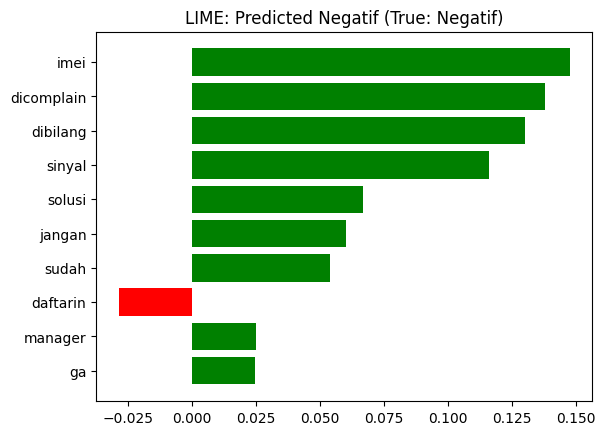


--- Explanation for Netral ---


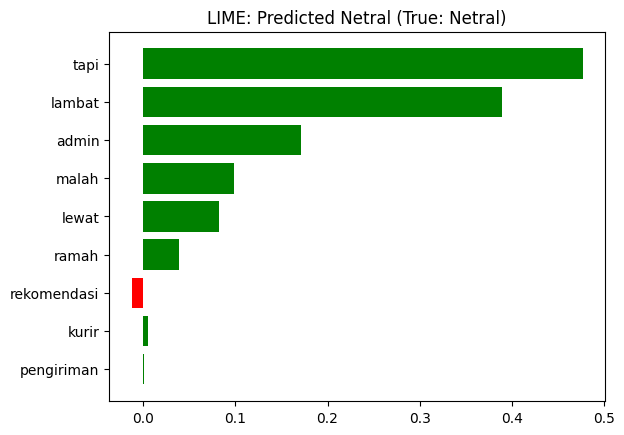


--- Explanation for Positif ---


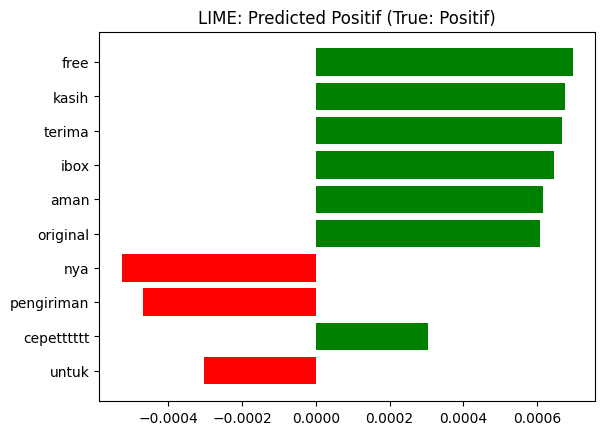

In [5]:
## 3. LIME Local Explanations

df = pd.read_csv(DATA_PATH)

# Select samples from each class
samples = df.groupby("sentiment_label").apply(lambda x: x.sample(1, random_state=42)).reset_index(drop=True)

explainer_lime = LimeTextExplainer(class_names=CLASS_NAMES)

for _, row in samples.iterrows():
    text = str(row["review_text_clean"])
    print(f"\n--- Explanation for {row['sentiment_label']} ---")
    exp = explainer_lime.explain_instance(
        text, predict_proba, num_features=10, labels=[0, 1, 2]
    )
    # Get explanation for predicted class
    pred_idx = predict_proba([text])[0].argmax()
    exp.as_pyplot_figure(label=pred_idx)
    plt.title(f"LIME: Predicted {CLASS_NAMES[pred_idx]} (True: {row['sentiment_label']})")
    plt.show()

In [6]:
## 4. SHAP Multi-class Explanations

def shap_predict(texts):
    return predict_proba([str(t) for t in texts])

masker = shap.maskers.Text(tokenizer=" ")
explainer_shap = shap.Explainer(shap_predict, masker, output_names=CLASS_NAMES)

shap_texts = samples["review_text_clean"].tolist()
shap_values = explainer_shap(shap_texts)

print("SHAP values computed.")

SHAP values computed.



SHAP Waterfall for Sample 1:


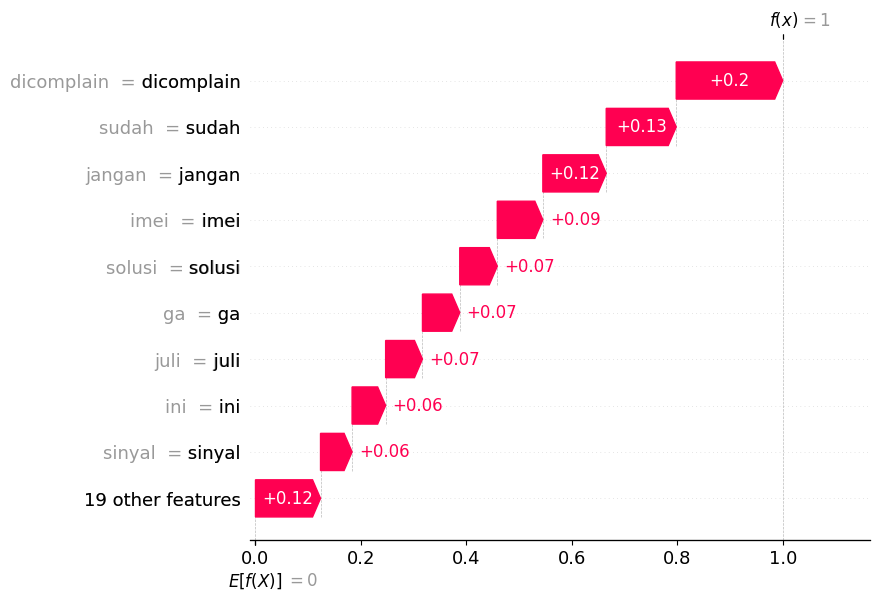


SHAP Waterfall for Sample 2:


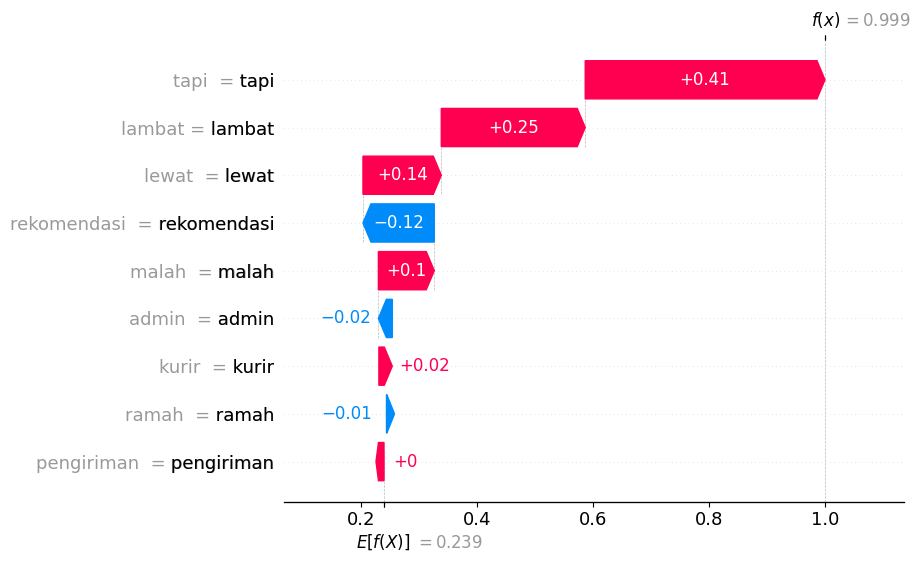


SHAP Waterfall for Sample 3:


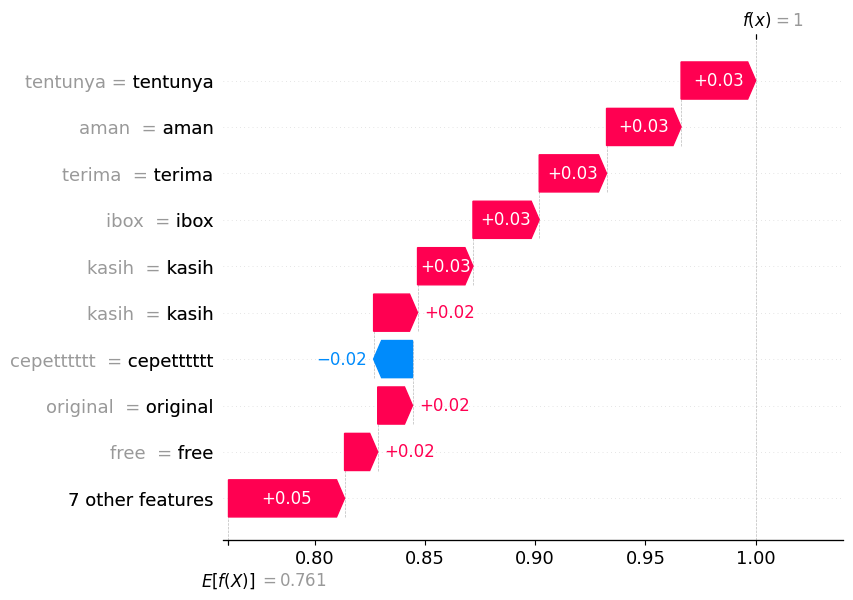

In [7]:
## 5. Visualizing SHAP for 3 classes

for i, text in enumerate(shap_texts):
    print(f"\nSHAP Waterfall for Sample {i+1}:")
    pred_idx = predict_proba([text])[0].argmax()
    shap.plots.waterfall(shap_values[i, :, pred_idx])
